# Customer Behavior & Revenue Analytics using SQL

This project analyzes an e-commerce transaction dataset using SQL to uncover
sales trends, customer purchasing behavior, and product demand patterns.

In [2]:
import pandas as pd

data = pd.read_excel("Online Retail.xlsx")
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Basic Data Exploration

In [3]:
data.shape

(541909, 8)

In [4]:
data.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [5]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Importing SQLlite

In [6]:
import sqlite3

conn = sqlite3.connect("data.db")
data.to_sql("ecommerce", conn, if_exists="replace", index=False)

541909

In [7]:
pd.read_sql_query(
"""
SELECT *
FROM ecommerce
LIMIT 10
""",
conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


Checking for Total Revenue

In [8]:
pd.read_sql(
    """
    select SUM(Quantity * UnitPrice) as totalRevenue
    from ecommerce
    """,
    conn
)

,totalRevenue
0,9.747748e+06


Checking TOP 10 Customers

In [9]:
pd.read_sql(
    """
    select CustomerID, SUM(Quantity * UnitPrice) as totalSpentByCustomer
    from ecommerce
    group by CustomerID
    order by totalSpentByCustomer desc
    limit 10
    """,
    conn
)

,CustomerID,totalSpentByCustomer
0,NaN,1447682.12
1,14646.0,279489.02
2,18102.0,256438.49
3,17450.0,187482.17
4,14911.0,132572.62
5,12415.0,123725.45
6,14156.0,113384.14
7,17511.0,88125.38
8,16684.0,65892.08
9,13694.0,62653.10


TOP 10 selling Products

In [10]:
pd.read_sql(
    """
    select Description, SUM(Quantity) as totalSold
    from ecommerce
    group by Description
    order by totalSold desc
    limit 10
    """,
    conn
)

,Description,totalSold
0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
1,JUMBO BAG RED RETROSPOT,47363
2,ASSORTED COLOUR BIRD ORNAMENT,36381
3,POPCORN HOLDER,36334
4,PACK OF 72 RETROSPOT CAKE CASES,36039
5,WHITE HANGING HEART T-LIGHT HOLDER,35317
6,RABBIT NIGHT LIGHT,30680
7,MINI PAINT SET VINTAGE,26437
8,PACK OF 12 LONDON TISSUES,26315
9,PACK OF 60 PINK PAISLEY CAKE CASES,24753


Revenue by Country

In [11]:
pd.read_sql(
    """
    select Country, SUM(Quantity * UnitPrice) as totalRevenue
    from ecommerce
    group by Country
    order by totalRevenue desc
    """,
    conn
)

,Country,totalRevenue
0,United Kingdom,8.187806e+06
1,Netherlands,2.846615e+05
2,EIRE,2.632768e+05
3,Germany,2.216982e+05
4,France,1.974039e+05
5,Australia,1.370773e+05
6,Switzerland,5.638535e+04
7,Spain,5.477458e+04
8,Belgium,4.091096e+04
9,Sweden,3.659591e+04


Monthly Revenue Trend

In [12]:
pd.read_sql(
    """
    select strftime('%Y-%m', InvoiceDate) as yearMonth, SUM(Quantity * UnitPrice) as totalRevenue
    from ecommerce
    group by yearMonth
    order by yearMonth
    """,
    conn
)

,yearMonth,totalRevenue
0,2010-12,748957.020
1,2011-01,560000.260
2,2011-02,498062.650
3,2011-03,683267.080
4,2011-04,493207.121
5,2011-05,723333.510
6,2011-06,691123.120
7,2011-07,681300.111
8,2011-08,682680.510
9,2011-09,1019687.622


Average Order Value

In [13]:
pd.read_sql_query("""
SELECT AVG(order_value) AS avgOrderValue
FROM (
    SELECT InvoiceNo,
    SUM(Quantity * UnitPrice) AS order_value
    FROM ecommerce
    GROUP BY InvoiceNo
)
""",
conn)

,avgOrderValue
0,376.360924


Orders per Customer

In [14]:
pd.read_sql_query("""
SELECT CustomerID,
COUNT(DISTINCT InvoiceNo) AS total_orders
FROM ecommerce
GROUP BY CustomerID
ORDER BY total_orders DESC
LIMIT 10
""",
conn)

,CustomerID,total_orders
0,NaN,3710
1,14911.0,248
2,12748.0,224
3,17841.0,169
4,14606.0,128
5,15311.0,118
6,13089.0,118
7,12971.0,89
8,14527.0,86
9,13408.0,81


Top Revenue Products

In [15]:
pd.read_sql_query("""
SELECT Description,
SUM(Quantity * UnitPrice) AS product_revenue
FROM ecommerce
GROUP BY Description
ORDER BY product_revenue DESC
LIMIT 10
""",
conn)

,Description,product_revenue
0,DOTCOM POSTAGE,206245.48
1,REGENCY CAKESTAND 3 TIER,164762.19
2,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
3,PARTY BUNTING,98302.98
4,JUMBO BAG RED RETROSPOT,92356.03
5,RABBIT NIGHT LIGHT,66756.59
6,POSTAGE,66230.64
7,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
8,ASSORTED COLOUR BIRD ORNAMENT,58959.73
9,CHILLI LIGHTS,53768.06


Top Revenue Months

In [16]:
pd.read_sql_query("""
SELECT strftime('%Y-%m', InvoiceDate) AS month,
SUM(Quantity * UnitPrice) AS revenue
FROM ecommerce
GROUP BY month
ORDER BY revenue DESC
LIMIT 5
""",
conn)

,month,revenue
0,2011-11,1461756.250
1,2011-10,1070704.670
2,2011-09,1019687.622
3,2010-12,748957.020
4,2011-05,723333.510


Top Revenue Months

In [17]:
pd.read_sql_query("""
SELECT CustomerID,
SUM(Quantity * UnitPrice) AS total_spent,
RANK() OVER (ORDER BY SUM(Quantity * UnitPrice) DESC) AS customer_rank
FROM ecommerce
GROUP BY CustomerID
LIMIT 10
""",
conn)

,CustomerID,total_spent,customer_rank
0,NaN,1447682.12,1
1,14646.0,279489.02,2
2,18102.0,256438.49,3
3,17450.0,187482.17,4
4,14911.0,132572.62,5
5,12415.0,123725.45,6
6,14156.0,113384.14,7
7,17511.0,88125.38,8
8,16684.0,65892.08,9
9,13694.0,62653.10,10


Number of Unique Products Sold

In [18]:
pd.read_sql_query("""
SELECT COUNT(DISTINCT StockCode) AS unique_products
FROM ecommerce
""", conn)

,unique_products
0,4070


Top Countries by Orders

In [19]:
pd.read_sql_query("""
SELECT Country,
COUNT(DISTINCT InvoiceNo) AS total_orders
FROM ecommerce
GROUP BY Country
ORDER BY total_orders DESC
LIMIT 10
""",
conn)

,Country,total_orders
0,United Kingdom,23494
1,Germany,603
2,France,461
3,EIRE,360
4,Belgium,119
5,Spain,105
6,Netherlands,101
7,Switzerland,74
8,Portugal,71
9,Australia,69


Customer Lifetime Value (CLV)

In [20]:
pd.read_sql_query("""
SELECT CustomerID,
SUM(Quantity * UnitPrice) AS lifetime_value
FROM ecommerce
GROUP BY CustomerID
ORDER BY lifetime_value DESC
LIMIT 10
""",
conn)

,CustomerID,lifetime_value
0,NaN,1447682.12
1,14646.0,279489.02
2,18102.0,256438.49
3,17450.0,187482.17
4,14911.0,132572.62
5,12415.0,123725.45
6,14156.0,113384.14
7,17511.0,88125.38
8,16684.0,65892.08
9,13694.0,62653.10


Monthly revenue trend

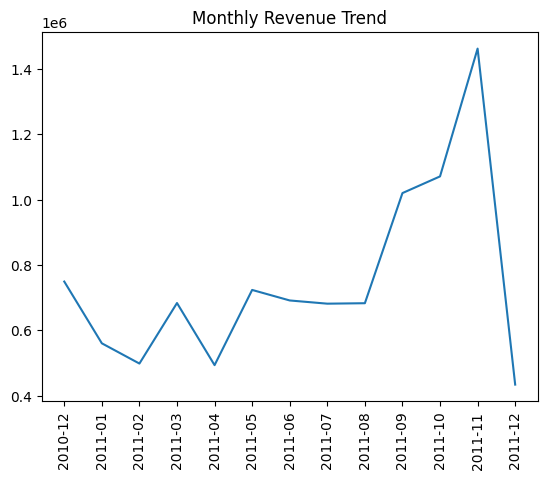

In [21]:
import matplotlib.pyplot as plt

monthly = pd.read_sql_query("""
SELECT strftime('%Y-%m', InvoiceDate) AS month,
SUM(Quantity * UnitPrice) AS revenue
FROM ecommerce
GROUP BY month
ORDER BY month
""", conn)

plt.plot(monthly['month'], monthly['revenue'])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.show()

Top 10 Products by Units Sold

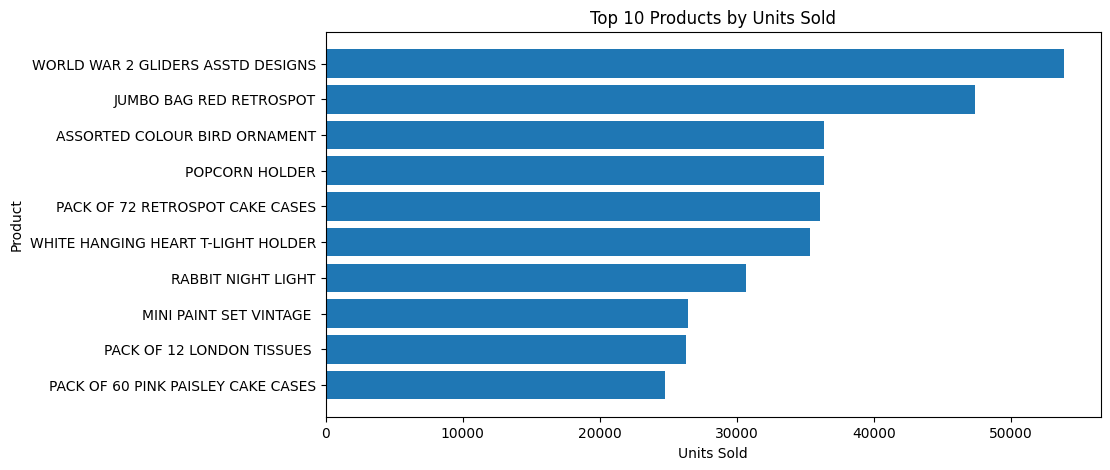

In [22]:
import matplotlib.pyplot as plt

top_products = pd.read_sql_query("""
SELECT Description,
SUM(Quantity) AS total_units_sold
FROM ecommerce
GROUP BY Description
ORDER BY total_units_sold DESC
LIMIT 10
""", conn)

plt.figure(figsize=(10,5))
plt.barh(top_products['Description'], top_products['total_units_sold'])
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.show()

Revenue by Country

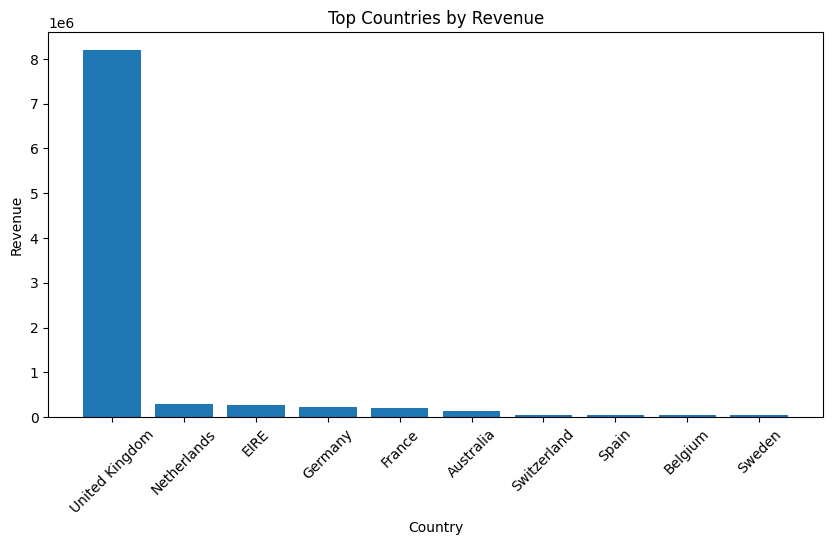

In [23]:
country_revenue = pd.read_sql_query("""
SELECT Country,
SUM(Quantity * UnitPrice) AS revenue
FROM ecommerce
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10
""", conn)

plt.figure(figsize=(10,5))
plt.bar(country_revenue['Country'], country_revenue['revenue'])
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Customer Value Segmentation

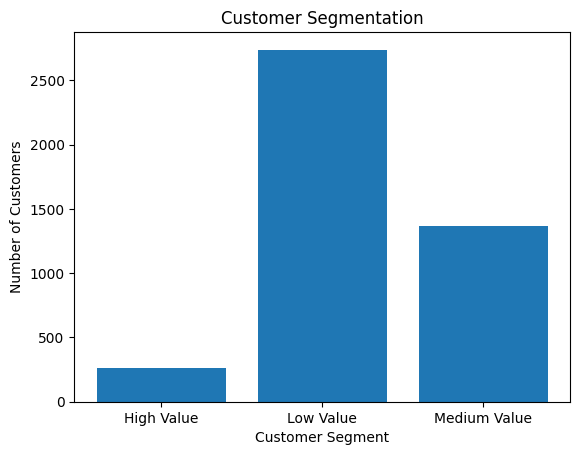

In [24]:
seg = pd.read_sql_query("""
SELECT
CASE
    WHEN totalSpent > 5000 THEN 'High Value'
    WHEN totalSpent BETWEEN 1000 AND 5000 THEN 'Medium Value'
    ELSE 'Low Value'
END AS segment,
COUNT(*) AS customers
FROM (
    SELECT CustomerID,
    SUM(Quantity * UnitPrice) AS totalSpent
    FROM ecommerce
    GROUP BY CustomerID
)
GROUP BY segment
""", conn)

import matplotlib.pyplot as plt

plt.bar(seg['segment'], seg['customers'])
plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

# Key Insights

1. Revenue Distribution
The majority of revenue comes from a few high-demand products, indicating that a small subset of items drives a large portion of total sales.

2. Customer Spending Behavior
A small group of customers contributes significantly to total revenue, showing the presence of high-value customers.

3. Geographic Sales Trends
Most revenue is generated from a few key countries, indicating that the business has strong demand in specific regions.

4. Product Demand
Certain products consistently rank among the top sellers, suggesting stable demand and opportunities for focused inventory management.

5. Sales Trends Over Time
Monthly revenue trends reveal fluctuations in sales across different months, indicating possible seasonal buying behavior.